In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb
from mplsoccer import Pitch

In [2]:
# 1. البحث عن الـ ID الصح لنهائي 2022 بالاسم
matches = sb.matches(competition_id=43, season_id=106)
final = matches[((matches.home_team == 'Argentina') & (matches.away_team == 'France')) | 
                ((matches.home_team == 'France') & (matches.away_team == 'Argentina'))]
true_id = final.match_id.values[0]

# 2. سحب أحداث الماتش بالـ ID اللي لقيناه
events = sb.events(match_id=true_id)

# 3. فلترة التسديدات وتجهيز الإحداثيات
shots = events[events['type'] == 'Shot'].copy()
shots[['x', 'y']] = shots['location'].apply(pd.Series)

# 4. تقسيم الفريقين
arg_shots = shots[shots['team'] == 'Argentina']
fra_shots = shots[shots['team'] == 'France']

print(f"Match ID Found: {true_id}")
print(f"Argentina Shots: {len(arg_shots)} | France Shots: {len(fra_shots)}")

Match ID Found: 3869685
Argentina Shots: 24 | France Shots: 14


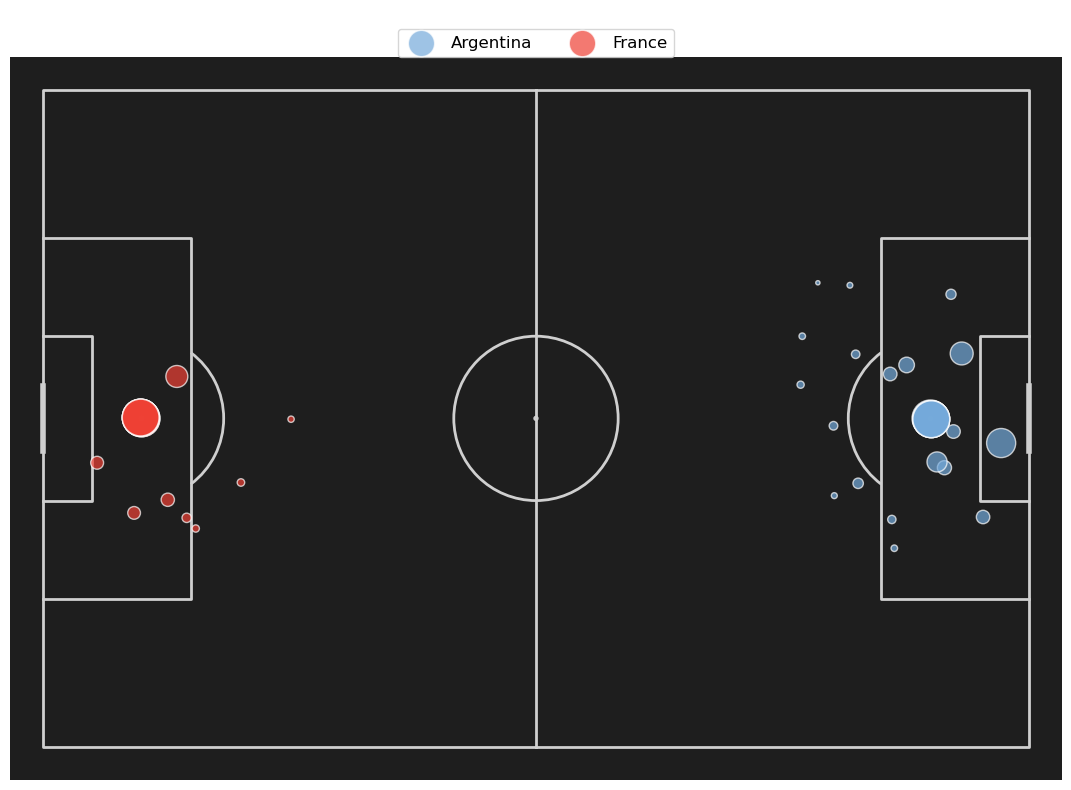

In [3]:

# 1. تجهيز الملعب بألوان احترافية (Dark Theme)
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e1e1e', line_color='#cfcfcf')
fig, ax = pitch.draw(figsize=(13, 8))

# 2. رسم تسديدات الأرجنتين (اللون السماوي)
# الحجم (s) يعبر عن خطورة التسديدة xG
pitch.scatter(arg_shots.x, arg_shots.y, 
              s=arg_shots['shot_statsbomb_xg'] * 900, 
              c='#75aadb', edgecolors='white', label='Argentina', ax=ax, alpha=0.7)

# 3. رسم تسديدات فرنسا (اللون الأحمر) في الجهة المقابلة
pitch.scatter(120 - fra_shots.x, 80 - fra_shots.y, 
              s=fra_shots['shot_statsbomb_xg'] * 900, 
              c='#ef4135', edgecolors='white', label='France', ax=ax, alpha=0.7)

# 4. حساب إجمالي الأهداف المتوقعة لكل فريق
arg_xg = arg_shots['shot_statsbomb_xg'].sum()
fra_xg = fra_shots['shot_statsbomb_xg'].sum()

# 5. إضافة العناوين والـ Legend
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=12)
plt.title(f"WC Final 2022: Argentina ({arg_xg:.2f} xG) vs France ({fra_xg:.2f} xG)", 
          color='white', size=18, pad=20)

plt.show()

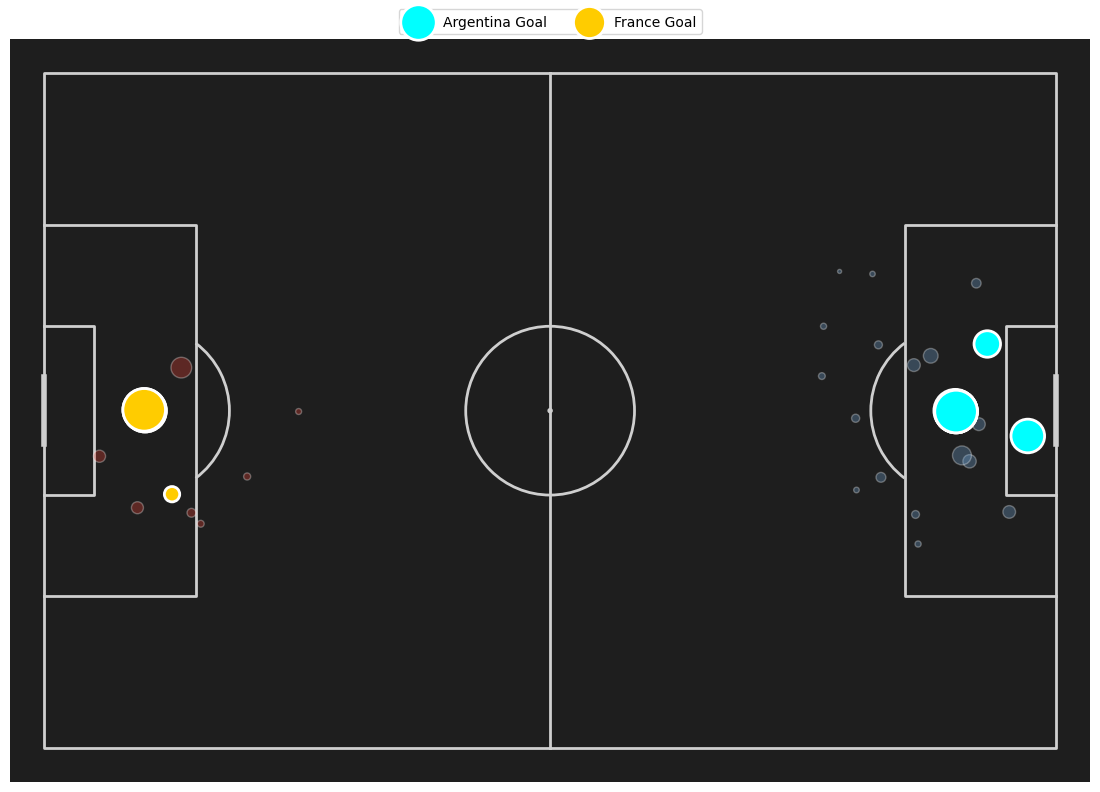

In [6]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# 1. فلترة الأهداف
arg_goals = arg_shots[arg_shots['shot_outcome'] == 'Goal'].copy()
fra_goals = fra_shots[fra_shots['shot_outcome'] == 'Goal'].copy()

# 2. رسم الملعب
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e1e1e', line_color='#cfcfcf')
fig, ax = pitch.draw(figsize=(13, 8))

# 3. رسم كل التسديدات (نصف شفافة)
pitch.scatter(arg_shots.x, arg_shots.y, s=arg_shots['shot_statsbomb_xg'] * 800, 
              c='#75aadb', edgecolors='white', alpha=0.3, ax=ax)
pitch.scatter(120 - fra_shots.x, 80 - fra_shots.y, s=fra_shots['shot_statsbomb_xg'] * 800, 
              c='#ef4135', edgecolors='white', alpha=0.3, ax=ax)

# 4. رسم "الأهداف" فقط (لون فاقع وإطار سميك)
pitch.scatter(arg_goals.x, arg_goals.y, s=arg_goals['shot_statsbomb_xg'] * 1200, 
              c='#00ffff', edgecolors='white', linewidth=2, label='Argentina Goal', ax=ax)
pitch.scatter(120 - fra_goals.x, 80 - fra_goals.y, s=fra_goals['shot_statsbomb_xg'] * 1200, 
              c='#ffcc00', edgecolors='white', linewidth=2, label='France Goal', ax=ax)

plt.title("Argentina vs France: Goals & Shots Map", color='white', size=18)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# 1. تجهيز بيانات الوقت والـ xG التراكمي
arg_shots['cum_xg'] = arg_shots['shot_statsbomb_xg'].cumsum()
fra_shots['cum_xg'] = fra_shots['shot_statsbomb_xg'].cumsum()

# 2. رسم المنحنى
plt.figure(figsize=(12, 6), facecolor='#1e1e1e')
ax = plt.gca()
ax.set_facecolor('#1e1e1e')

plt.step(arg_shots['minute'], arg_shots['cum_xg'], where='post', color='#75aadb', label='Argentina', linewidth=3)
plt.step(fra_shots['minute'], fra_shots['cum_xg'], where='post', color='#ef4135', label='France', linewidth=3)

# 3. تنسيق الرسمة
plt.xlabel('Minute', color='white', fontsize=12)
plt.ylabel('Cumulative xG', color='white', fontsize=12)
plt.title('Argentina vs France: The xG Race', color='white', fontsize=16, pad=20)
plt.xticks(color='white')
plt.yticks(color='white')
plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.legend(fontsize=12)

plt.show()

C:\Users\RePack\AppData\Local\Temp\ipykernel_25608\2132843733.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  arg_shots['cum_xg'] = arg_shots['shot_statsbomb_xg'].cumsum()
C:\Users\RePack\AppData\Local\Temp\ipykernel_25608\2132843733.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fra_shots['cum_xg'] = fra_shots['shot_statsbomb_xg'].cumsum()


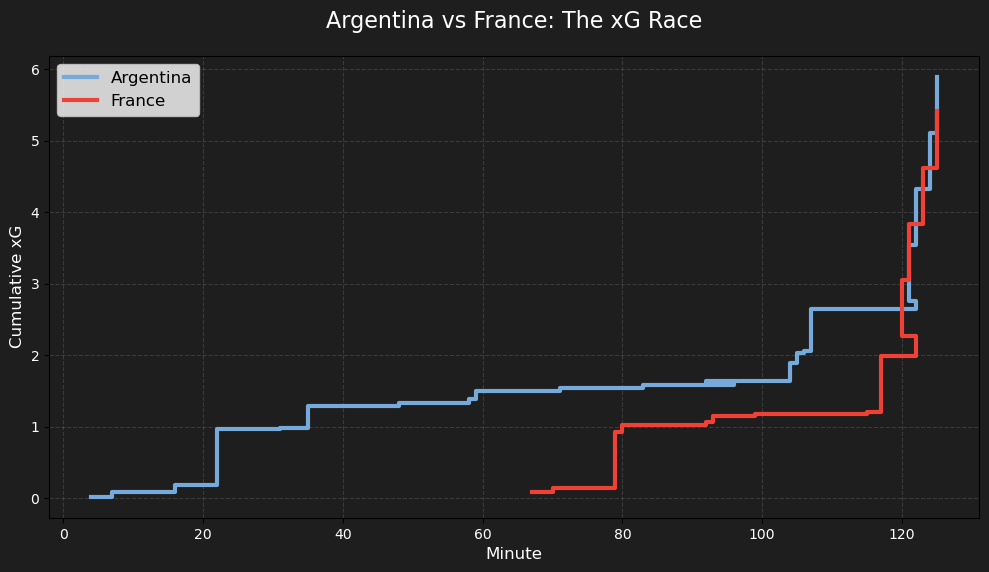

In [7]:
import matplotlib.pyplot as plt

# 1. تجهيز بيانات الوقت والـ xG التراكمي
arg_shots['cum_xg'] = arg_shots['shot_statsbomb_xg'].cumsum()
fra_shots['cum_xg'] = fra_shots['shot_statsbomb_xg'].cumsum()

# 2. رسم المنحنى
plt.figure(figsize=(12, 6), facecolor='#1e1e1e')
ax = plt.gca()
ax.set_facecolor('#1e1e1e')

plt.step(arg_shots['minute'], arg_shots['cum_xg'], where='post', color='#75aadb', label='Argentina', linewidth=3)
plt.step(fra_shots['minute'], fra_shots['cum_xg'], where='post', color='#ef4135', label='France', linewidth=3)

# 3. تنسيق الرسمة
plt.xlabel('Minute', color='white', fontsize=12)
plt.ylabel('Cumulative xG', color='white', fontsize=12)
plt.title('Argentina vs France: The xG Race', color='white', fontsize=16, pad=20)
plt.xticks(color='white')
plt.yticks(color='white')
plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.legend(fontsize=12)

plt.show()

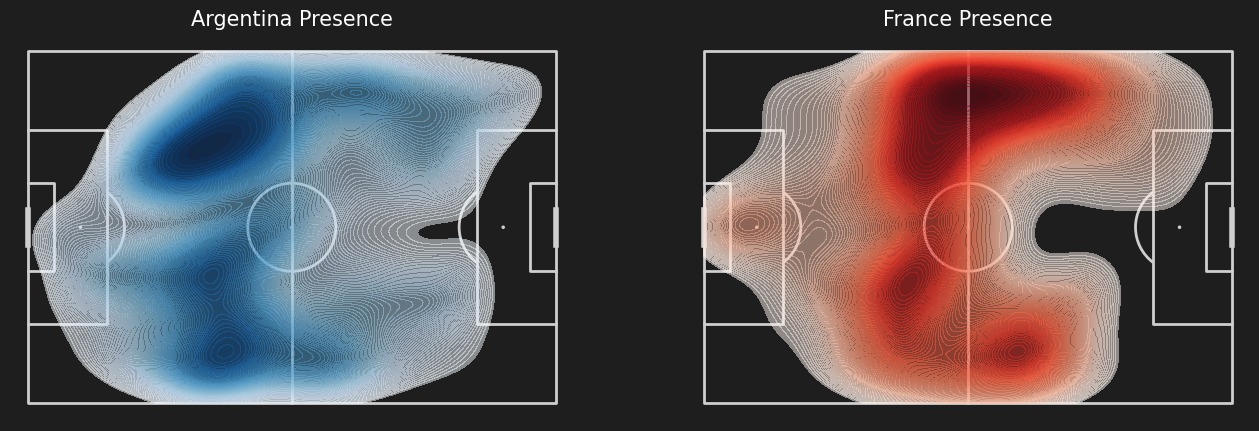

In [8]:
# 1. تجهيز البيانات (إحداثيات كل الأحداث)
events_h = events.dropna(subset=['location']).copy()
events_h[['x', 'y']] = events_h['location'].apply(pd.Series)

arg_h = events_h[events_h['team'] == 'Argentina']
fra_h = events_h[events_h['team'] == 'France']

# 2. رسم الـ Heatmap
fig, ax = plt.subplots(1, 2, figsize=(16, 8), facecolor='#1e1e1e')

# ملعب الأرجنتين
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e1e1e', line_color='#cfcfcf')
pitch.draw(ax=ax[0])
pitch.kdeplot(arg_h.x, arg_h.y, ax=ax[0], cmap='Blues', fill=True, levels=100, thresh=0.1, alpha=0.5)
ax[0].set_title("Argentina Presence", color='white', size=15)

# ملعب فرنسا
pitch.draw(ax=ax[1])
pitch.kdeplot(fra_h.x, fra_h.y, ax=ax[1], cmap='Reds', fill=True, levels=100, thresh=0.1, alpha=0.5)
ax[1].set_title("France Presence", color='white', size=15)

plt.show()

In [14]:
# 1. البحث عن ميسي ومبابي بأي جزء من اسمهم
messi_data = events[events['player'].str.contains('Lionel', na=False)]
mbappe_data = events[events['player'].str.contains('Kylian', na=False)]

# 2. حساب الـ xG من التسديدات
messi_xg = messi_data[messi_data['type'] == 'Shot']['shot_statsbomb_xg'].sum()
mbappe_xg = mbappe_data[mbappe_data['type'] == 'Shot']['shot_statsbomb_xg'].sum()

# 3. حساب التمريرات الصحيحة (اللي الـ outcome بتاعها NaN يعني كملت)
messi_p = len(messi_data[(messi_data['type'] == 'Pass') & (messi_data['pass_outcome'].isna())])
mbappe_p = len(mbappe_data[(mbappe_data['type'] == 'Pass') & (mbappe_data['pass_outcome'].isna())])

print(f"--- Updated Player Comparison ---")
print(f"Messi  | xG: {messi_xg:.2f} | Completed Passes: {messi_p}")
print(f"Mbappé | xG: {mbappe_xg:.2f} | Completed Passes: {mbappe_p}")

--- Updated Player Comparison ---
Messi  | xG: 2.24 | Completed Passes: 49
Mbappé | xG: 2.57 | Completed Passes: 19


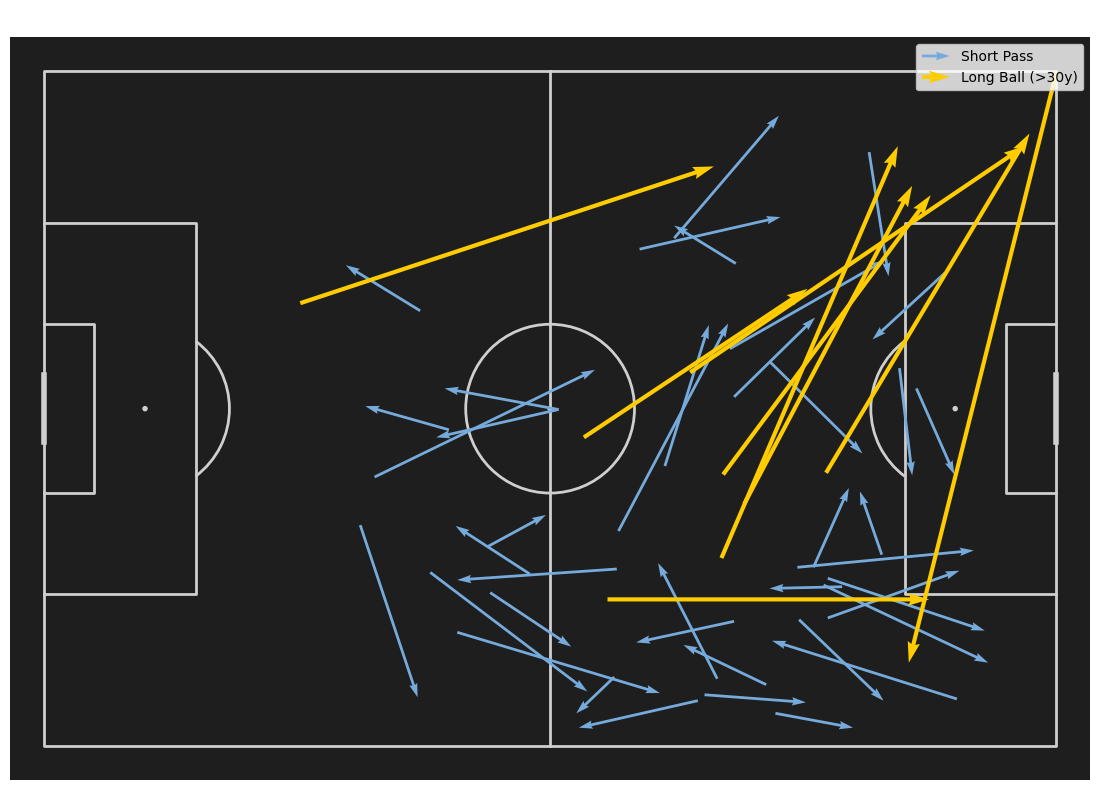

In [15]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import numpy as np

# 1. فلترة تمريرات ميسي وتجهيز الإحداثيات
messi_p = events[(events['type'] == 'Pass') & 
                (events['player'].str.contains('Lionel', na=False)) & 
                (events['pass_outcome'].isna())].copy()

messi_p[['x', 'y']] = pd.DataFrame(messi_p['location'].tolist(), index=messi_p.index)
messi_p[['ex', 'ey']] = pd.DataFrame(messi_p['pass_end_location'].tolist(), index=messi_p.index)

# 2. حساب طول التمريرة (Euclidean Distance)
messi_p['distance'] = np.sqrt((messi_p.ex - messi_p.x)**2 + (messi_p.ey - messi_p.y)**2)

# 3. تقسيم التمريرات (طويلة وقصيرة)
long_p = messi_p[messi_p['distance'] > 30]
short_p = messi_p[messi_p['distance'] <= 30]

# 4. الرسم
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e1e1e', line_color='#cfcfcf')
fig, ax = pitch.draw(figsize=(13, 8))

# رسم القصير بالسماوي
pitch.arrows(short_p.x, short_p.y, short_p.ex, short_p.ey, 
             width=2, color='#75aadb', ax=ax, label='Short Pass')

# رسم الطويل بالأصفر
pitch.arrows(long_p.x, long_p.y, long_p.ex, long_p.ey, 
             width=3, color='#ffcc00', ax=ax, label='Long Ball (>30y)')

plt.title(f"Messi Playmaking: {len(long_p)} Long Balls Found", color='white', size=18)
plt.legend()
plt.show()

In [16]:
# 1. فلترة أحداث الجري بالكورة (Carries) وفك الإحداثيات
carries = events[events['type'] == 'Carry'].copy()
carries[['x', 'y']] = pd.DataFrame(carries['location'].tolist(), index=carries.index)
carries[['ex', 'ey']] = pd.DataFrame(carries['carry_end_location'].tolist(), index=carries.index)

# 2. حساب المسافة المقطوعة في اتجاه المرمى (التقدم للأمام فقط)
carries['prog_dist'] = carries['ex'] - carries['x']

# 3. تجميع المسافات لكل لاعب وترتيبهم
top_carriers = carries.groupby('player')['prog_dist'].sum().sort_values(ascending=False)

print("--- Top 5 Players (Progressive Carrying Distance) ---")
print(top_carriers.head(5))

--- Top 5 Players (Progressive Carrying Distance) ---
player
Lionel Andrés Messi Cuccittini    244.5
Raphaël Varane                    188.9
Kylian Mbappé Lottin              171.4
Jules Koundé                      158.7
Dayotchanculle Upamecano          153.3
Name: prog_dist, dtype: float64


--- Top 5 Pressurers (The Engines) ---
player
Enzo Fernandez       30
Randal Kolo Muani    29
Julián Álvarez       27
Adrien Rabiot        20
Marcus Thuram        20
dtype: int64


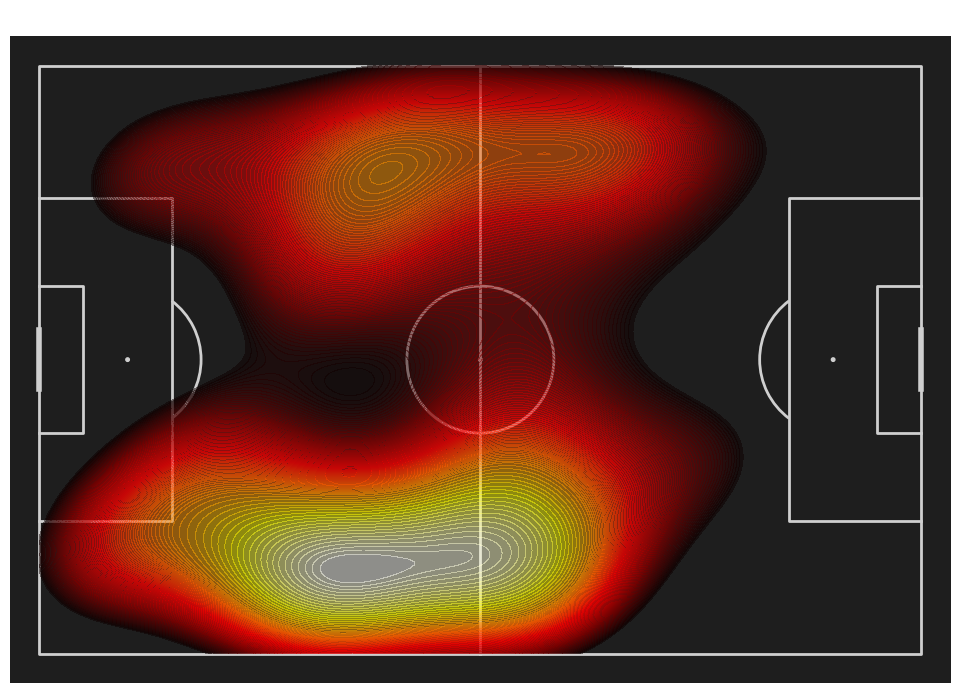

In [17]:
# 1. فلترة أحداث الضغط (Pressure)
pressure_events = events[events['type'] == 'Pressure'].copy()

# 2. تجميع أكتر 5 لاعيبة "مزعجين" في الماتش
top_pressurers = pressure_events.groupby('player').size().sort_values(ascending=False)

print("--- Top 5 Pressurers (The Engines) ---")
print(top_pressurers.head(5))

# 3. رسم أماكن الضغط (Heatmap للضغط فقط)
import matplotlib.pyplot as plt
from mplsoccer import Pitch

pressure_events[['x', 'y']] = pd.DataFrame(pressure_events['location'].tolist(), index=pressure_events.index)

pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e1e1e', line_color='#cfcfcf')
fig, ax = pitch.draw(figsize=(10, 7))

# رسم خريطة حرارية للضغط
pitch.kdeplot(pressure_events.x, pressure_events.y, ax=ax, cmap='hot', fill=True, levels=100, thresh=0.2, alpha=0.5)

plt.title("Where the Pressure Happened (High Intensity Zones)", color='white', size=16)
plt.show()

--- Top 5 Ball Winners (The Wall) ---
player                     team     
Aurélien Djani Tchouaméni  France       15
Alexis Mac Allister        Argentina     9
Enzo Fernandez             Argentina     9
Adrien Rabiot              France        7
Nicolás Hernán Otamendi    Argentina     7
dtype: int64


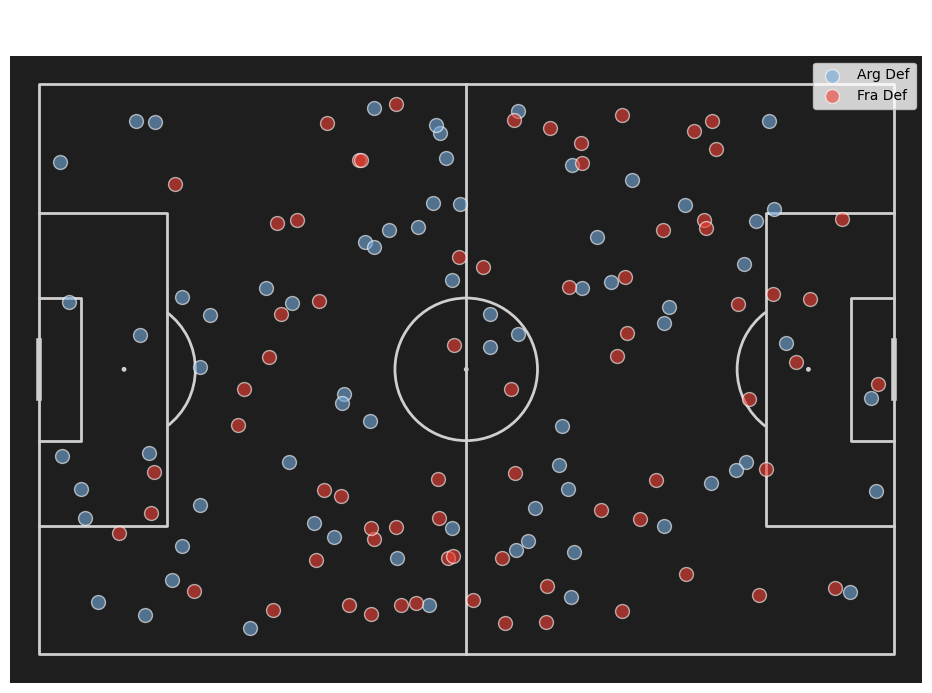

In [18]:
# 1. فلترة أحداث الدفاع (Interception, Tackle, Ball Recovery)
defensive_actions = events[events['type'].isin(['Interception', 'Tackle', 'Ball Recovery'])].copy()

# 2. حساب أكتر لاعب قطع الكورة في الماتش
ball_winners = defensive_actions.groupby(['player', 'team']).size().sort_values(ascending=False)

print("--- Top 5 Ball Winners (The Wall) ---")
print(ball_winners.head(5))

# 3. رسم أماكن التدخلات الدفاعية (Defensive Actions Map)
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# فك الإحداثيات
defensive_actions[['x', 'y']] = pd.DataFrame(defensive_actions['location'].tolist(), index=defensive_actions.index)

pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e1e1e', line_color='#cfcfcf')
fig, ax = pitch.draw(figsize=(10, 7))

# رسم النقط اللي اتقطع فيها الكورة (الأرجنتين بالأزرق وفرنسا بالأحمر)
arg_def = defensive_actions[defensive_actions['team'] == 'Argentina']
fra_def = defensive_actions[defensive_actions['team'] == 'France']

pitch.scatter(arg_def.x, arg_def.y, s=100, c='#75aadb', edgecolors='white', label='Arg Def', ax=ax, alpha=0.6)
pitch.scatter(120 - fra_def.x, 80 - fra_def.y, s=100, c='#ef4135', edgecolors='white', label='Fra Def', ax=ax, alpha=0.6)

plt.title("Defensive Actions: Where the Ball Was Won", color='white', size=16, pad=20)
plt.legend()
plt.show()

--- Top Chance Creators (Key Passes) ---
player                           team     
Ángel Fabián Di María Hernández  Argentina    4
Gonzalo Ariel Montiel            Argentina    2
Marcos Javier Acuña              Argentina    2
Lionel Andrés Messi Cuccittini   Argentina    2
Enzo Fernandez                   Argentina    1
dtype: int64


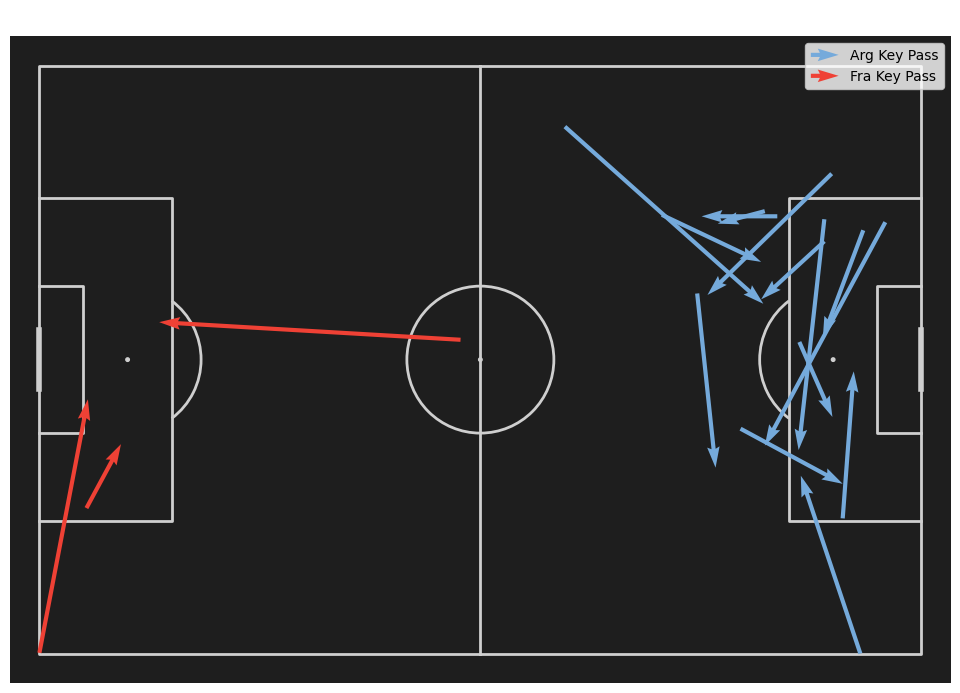

In [19]:
# 1. فلترة التمريرات اللي أدت لتسديدة (Shot Assists)
shot_assists = events[events['pass_shot_assist'] == True].copy()

# 2. فك الإحداثيات
shot_assists[['x', 'y']] = pd.DataFrame(shot_assists['location'].tolist(), index=shot_assists.index)
shot_assists[['ex', 'ey']] = pd.DataFrame(shot_assists['pass_end_location'].tolist(), index=shot_assists.index)

# 3. حساب أكتر صانع فرص في الماتش
top_creators = shot_assists.groupby(['player', 'team']).size().sort_values(ascending=False)

print("--- Top Chance Creators (Key Passes) ---")
print(top_creators.head(5))

# 4. رسم خريطة التمريرات المفتاحية
import matplotlib.pyplot as plt
from mplsoccer import Pitch

pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e1e1e', line_color='#cfcfcf')
fig, ax = pitch.draw(figsize=(10, 7))

# رسم أسهم التمريرات (الأرجنتين سماوي، فرنسا أحمر)
arg_sa = shot_assists[shot_assists['team'] == 'Argentina']
fra_sa = shot_assists[shot_assists['team'] == 'France']

pitch.arrows(arg_sa.x, arg_sa.y, arg_sa.ex, arg_sa.ey, color='#75aadb', width=3, label='Arg Key Pass', ax=ax)
pitch.arrows(120 - fra_sa.x, 80 - fra_sa.y, 120 - fra_sa.ex, 80 - fra_sa.ey, color='#ef4135', width=3, label='Fra Key Pass', ax=ax)

plt.title("Key Passes: Passes Leading to a Shot", color='white', size=16)
plt.legend()
plt.show()


In [20]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# 1. فلترة كل لمسات ميسي (كل الأحداث اللي عملها)
messi_touches = events[events['player'].str.contains('Lionel', na=False)].copy()

# 2. فك الإحداثيات
messi_touches[['x', 'y']] = pd.DataFrame(messi_touches['location'].tolist(), index=messi_touches.index)

# 3. رسم الملعب والـ Heatmap
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e1e1e', line_color='#cfcfcf')
fig, ax = pitch.draw(figsize=(10, 7))

# رسم خريطة حرارية للمسات
pitch.kdeplot(messi_touches.x, messi_touches.y, ax=ax, cmap='Blues', fill=True, levels=100, thresh=0.1, alpha=0.5)

# رسم النقط الفعلية للمسات
pitch.scatter(messi_touches.x, messi_touches.y, s=20, c='#75aadb', edgecolors='white', linewidth=0.5, alpha=0.6, ax=ax)

plt.title(f"Lionel Messi: {len(messi_touches)} Total Touches", color='white', size=16, pad=20)
plt.show()


TypeError: object of type 'float' has no len()